# Ансамбль әдістері: Бэггинг, Бустинг және Стекинг


**Мақсат:** Осы тәжірибелік жұмыста сіз ансамбль әдістерінің негізгі түрлерімен танысасыз: бэггинг, градиенттік бустинг және стекинг. Әр бөлімде теориялық түсіндірме берілген, содан кейін тапсырмаларды өз бетіңізше орындайсыз.



## Қажетті кітапханаларды жүктеу

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Кітапханалар сәтті жүктелді.")

Кітапханалар сәтті жүктелді.




# 1-бөлім. Ансамбль әдістеріне кіріспе

**Мақсат:** Ансамбль әдістерінің негізгі идеясын түсіну және олардың неге жақсы нәтиже беретінін анықтау.

## Теориялық негіз

Ансамбль әдісі дегеніміз — бірнеше модельді бірге пайдаланып, олардың жауаптарын біріктіретін тәсіл. Идея өте қарапайым: бір ғана адамның пікіріне қарағанда, бірнеше тәжірибелі адамның ортақ шешімі дұрысырақ болады.

Машиналық оқытуда жеке модель жиі екі мәселеге тап болады:

- **Жоғары дисперсия (high variance):** Модель оқу деректеріне тым үйреніп, жаңа деректерде нашар жұмыс жасайды. Бұл асып оқыту (overfitting) деп аталады.
- **Жоғары ауытқу (high bias):** Модель тым қарапайым болып, деректердегі заңдылықты үйрене алмайды. Бұл аз оқыту (underfitting) деп аталады.

Ансамбль әдістері осы екі мәселені де жеңілдетеді.

Ансамбль әдістерінің үш негізгі түрі бар:

1. **Бэггинг (Bagging):** Модельдер бір-бірінен тәуелсіз оқытылады, содан кейін олардың жауаптары орташаланады немесе дауыс беру арқылы біріктіріледі.
2. **Бустинг (Boosting):** Модельдер кезекпен оқытылады; әрбір жаңа модель алдыңғысының қателерін түзетуге тырысады.
3. **Стекинг (Stacking):** Бірнеше базалық модельдің жауаптары мета-модельге берілед, ол соңғы болжамды жасайды.

## Деректерді дайындау

Осы тәжірибелік жұмыста біз Breast Cancer деректер жиынын қолданамыз. Бұл жиын қатерлі ісіктің қатерлі (malignant) немесе қатерсіз (benign) екенін анықтауға арналған.

In [3]:
# Деректерді жүктеу
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Деректер жиынының өлшемі:", X.shape)
print("Класс бөлінісі:")
print(y.value_counts().rename({0: 'Қатерлі', 1: 'Қатерсіз'}))

Деректер жиынының өлшемі: (569, 30)
Класс бөлінісі:
target
Қатерсіз    357
Қатерлі     212
Name: count, dtype: int64


In [4]:
# Деректерді оқыту және тексеру жиындарына бөлу
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Оқыту жиыны:", X_train.shape)
print("Тексеру жиыны:", X_test.shape)

Оқыту жиыны: (455, 30)
Тексеру жиыны: (114, 30)


### Базалық модельмен салыстыру

Ансамбль әдістерінің тиімділігін көрсету үшін алдымен жеке шешім ағашының нәтижесін алайық.

In [ ]:
# Жеке шешім ағашы — базалық модель
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
y_pred_tree = single_tree.predict(X_test)

print("Жеке шешім ағашының дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_tree)))

Жеке шешім ағашының дәлдігі: 0.9123


### Тапсырма 1.1

Жеке шешім ағашының тереңдігін (max_depth) 3, 5, 10 және None мәндерімен сынап көріңіз. Тексеру жиынындағы дәлдікті есептеп, қайсысы жақсы нәтиже беретінін анықтаңыз.

In [5]:
# TODO: max_depth мәндерін тізімге жазыңыз
depths = [3, 5, 10, None]
results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "max_depth": depth,
        "accuracy": acc
    })

results_df = pd.DataFrame(results)
print(results_df)

best = results_df.loc[results_df["accuracy"].idxmax()]
print("Ең жақсы max_depth:", best["max_depth"])
print("Ең жақсы дәлдік:", best["accuracy"])

   max_depth  accuracy
0        3.0  0.938596
1        5.0  0.921053
2       10.0  0.912281
3        NaN  0.912281
Ең жақсы max_depth: 3.0
Ең жақсы дәлдік: 0.9385964912280702




# 2-бөлім. Бэггинг және Кездейсоқ Орман

**Мақсат:** Бэггинг алгоритмінің жұмыс принципін түсіну және Кездейсоқ Ормандарды қолдана білу.

## Теориялық негіз

### Бэггинг (Bootstrap Aggregating)

Бэггингтің атауы екі сөзден тұрады: Bootstrap (іріктеу) және Aggregating (біріктіру).

Алгоритм мынадай жұмыс жасайды:

1. Бастапқы оқыту жиынынан қайтарыммен (with replacement) кездейсоқ ішкі жиын (bootstrap sample) алынады.
2. Әрбір ішкі жиын бойынша жеке модель (базалық оқытушы) оқытылады.
3. Болжам жасау кезінде барлық модельдердің жауаптары біріктіріледі: классификация үшін — дауыс беру, регрессия үшін — орташалау.

Бэггинг дисперсияны азайтады, себебі кездейсоқ жасалған модельдердің қателері бір-бірін жойып жіберуге бейім.

### Кездейсоқ Орман (Random Forest)

Кездейсоқ Орман — бэггингтің жетілдірілген нұсқасы. Негізгі айырмашылығы: әрбір бұтақ бөлінісінде барлық белгілер емес, олардың кездейсоқ ішкі жиыны қарастырылады. Бұл модельдер арасындағы корреляцияны азайтады және жиынтық болжамды жақсартады.

Кездейсоқ Орманның негізгі гиперпараметрлері:

- `n_estimators` — ағаштар саны
- `max_depth` — ағаш тереңдігі
- `max_features` — әр бөліністе қарастырылатын белгілер үлесі
- `min_samples_split` — бөліну үшін қажетті ең аз мысал саны

In [7]:
# Бэггинг классификаторы
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)
bagging_clf.fit(X_train, y_train)
y_pred_bagging = bagging_clf.predict(X_test)

print("Бэггинг дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_bagging)))

Бэггинг дәлдігі: 0.9386


In [8]:
# Кездейсоқ Орман классификаторы
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Кездейсоқ Орман дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_rf)))
print()
print("Толық есеп:")
print(classification_report(y_test, y_pred_rf, target_names=['Қатерлі', 'Қатерсіз']))

Кездейсоқ Орман дәлдігі: 0.9561

Толық есеп:
              precision    recall  f1-score   support

     Қатерлі       0.95      0.93      0.94        42
    Қатерсіз       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Белгілердің маңыздылығы

Кездейсоқ Орман моделі белгілердің маңыздылығын (feature importance) анықтауға мүмкіндік береді. Бұл деректер жиынындағы қай белгілер болжамға ең көп үлес қосатынын көруге көмектеседі.

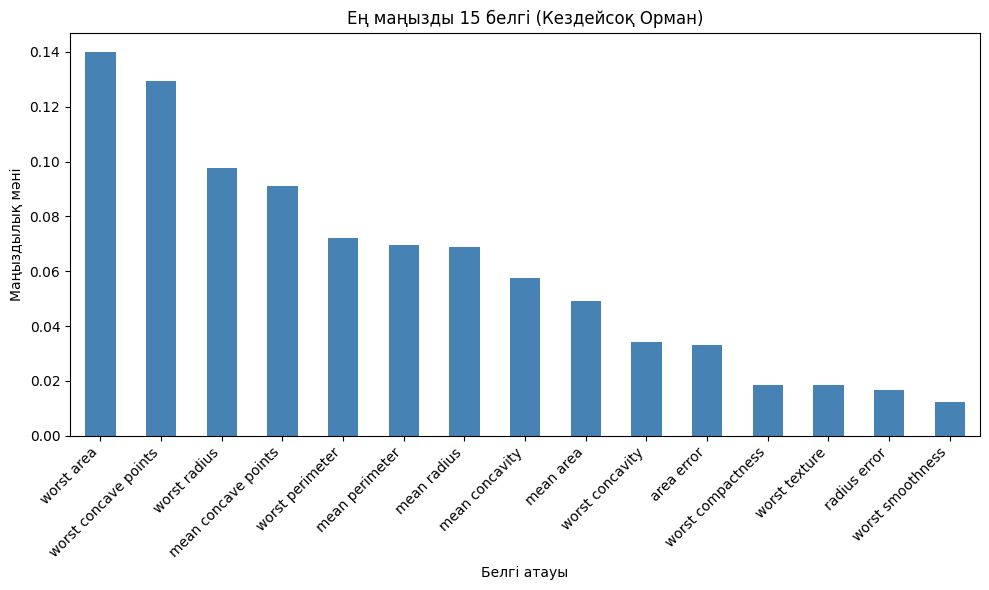

In [9]:
# Белгілердің маңыздылығын визуализациялау
feature_importance = pd.Series(
    rf_clf.feature_importances_,
    index=data.feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance[:15].plot(kind='bar', color='steelblue')
plt.title('Ең маңызды 15 белгі (Кездейсоқ Орман)')
plt.xlabel('Белгі атауы')
plt.ylabel('Маңыздылық мәні')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Тапсырма 2.1

Кездейсоқ Орман моделін n_estimators параметрі 10, 50, 100, 200, 500 мәндерімен оқытыңыз. Ағаштар саны артқан сайын дәлдіктің қалай өзгеретінін графикте көрсетіңіз. Оқыту дәлдігі мен тексеру дәлдігін бір графикте салыстырыңыз.

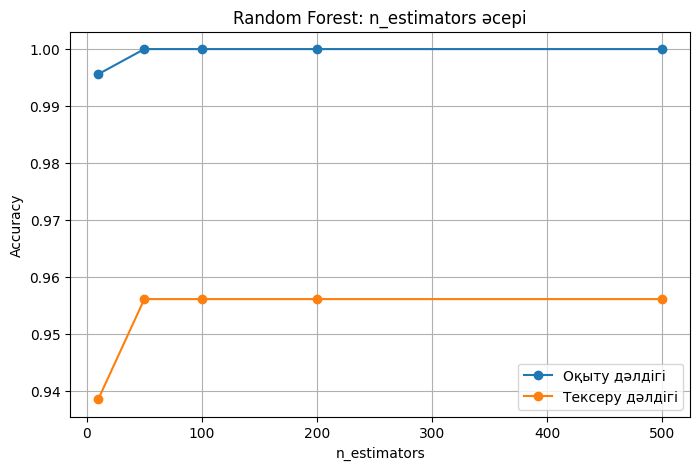

In [10]:
# TODO: n_estimators мәндерін тізімге жазыңыз
n_trees_list = [10, 50, 100, 200, 500]
train_scores = []
test_scores = []

for n_trees in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf.fit(X_train, y_train)

    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)

    train_scores.append(accuracy_score(y_train, train_pred))
    test_scores.append(accuracy_score(y_test, test_pred))

plt.figure(figsize=(8, 5))
plt.plot(n_trees_list, train_scores, marker='o', label='Оқыту дәлдігі')
plt.plot(n_trees_list, test_scores, marker='o', label='Тексеру дәлдігі')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest: n_estimators әсері')
plt.legend()
plt.grid(True)
plt.show()


### Тапсырма 2.2

Out-of-Bag (OOB) қатені есептеңіз. OOB — бутстрэп іріктемесіне кірмеген мысалдар. Олар сол модельді бағалау үшін пайдаланылады. RandomForestClassifier ішінде oob_score=True параметрін орнатып, OOB дәлдігін шығарыңыз. Тексеру жиынының дәлдігімен салыстырыңыз.

In [11]:
rf_oob = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf_oob.fit(X_train, y_train)

y_pred_oob = rf_oob.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_oob)

print("OOB дәлдігі:", rf_oob.oob_score_)
print("Тексеру дәлдігі:", test_acc)

OOB дәлдігі: 0.9538461538461539
Тексеру дәлдігі: 0.956140350877193


### Тапсырма 2.3

make_classification функциясымен жасанды деректер жасаңыз (n_samples=1000, n_features=20, n_informative=10). Жеке шешім ағашы мен Кездейсоқ Орманды 5-кат айқастыру тексеруімен (cross_val_score) салыстырыңыз. Орташа мән мен стандартты ауытқуды бірге шығарыңыз.

In [12]:
X_syn, y_syn = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    random_state=42
)

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

dt_scores = cross_val_score(dt, X_syn, y_syn, cv=5)
rf_scores = cross_val_score(rf, X_syn, y_syn, cv=5)

results = pd.DataFrame({
    "Модель": ["Decision Tree", "Random Forest"],
    "Орташа мән": [dt_scores.mean(), rf_scores.mean()],
    "Стандартты ауытқу": [dt_scores.std(), rf_scores.std()]
})

print(results)

          Модель  Орташа мән  Стандартты ауытқу
0  Decision Tree       0.833           0.012083
1  Random Forest       0.933           0.013266




# 3-бөлім. Адаптивті Бустинг (AdaBoost)

**Мақсат:** Бустингтің жұмыс принципін AdaBoost мысалы арқылы түсіну және learning_rate гиперпараметрінің рөлін зерттеу.

## Теориялық негіз

Бустинг — модельдерді кезекпен оқыту тәсілі. Негізгі идея: әрбір жаңа модель алдыңғы модельдер дұрыс жіктей алмаған мысалдарға көбірек назар аударады.

AdaBoost (Adaptive Boosting) алгоритмі мынадай жұмыс жасайды:

1. Алғашқыда барлық мысалдардың салмағы тең болады.
2. Бірінші базалық оқытушы оқытылады.
3. Қате жіктелген мысалдардың салмағы артырылады, дұрыс жіктелгендердің салмағы азайтылады.
4. Екінші базалық оқытушы жаңартылған салмақтармен оқытылады.
5. Осы процесс n_estimators рет қайталанады.
6. Соңғы болжам барлық оқытушылардың салмақталған дауысы негізінде жасалады.

AdaBoostта базалық оқытушы ретінде әдетте тереңдігі 1 болатын шешім ағаштары (decision stumps) қолданылады. Бұл мысалдарды тек бір ережемен ажырататын өте қарапайым ағаштар.

Негізгі гиперпараметрлер:

- `n_estimators` — базалық оқытушылар саны
- `learning_rate` — оқыту жылдамдығы; үлкен мән жылдам оқытады, бірақ асып оқытуға жол ашуы мүмкін

Бустинг пен бэггингтің айырмашылығы мынада: бэггинг дисперсияны азайтады, ал бустинг бастапқы нысаналы міндет — ауытқуды (bias) азайту.

In [13]:
# AdaBoost классификаторы
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)

print("AdaBoost дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_ada)))

AdaBoost дәлдігі: 0.9561


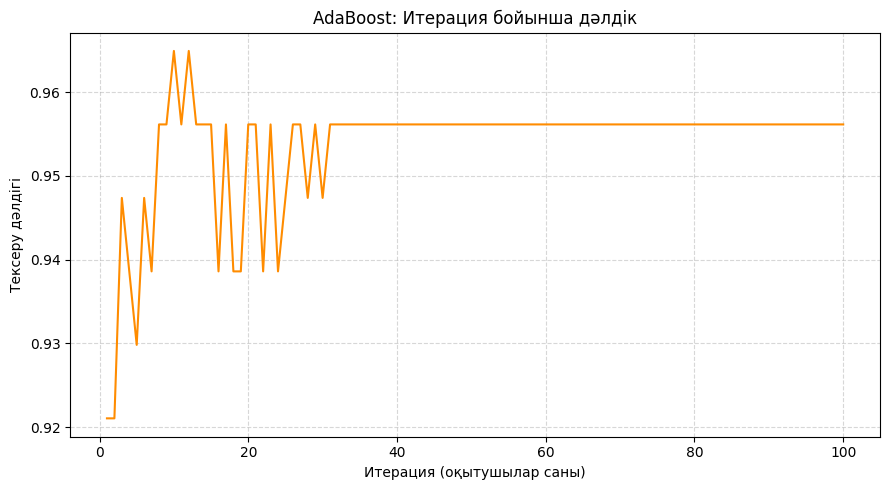

In [14]:
# Итерация бойынша дәлдіктің өзгеруін бақылау
staged_preds = list(ada_clf.staged_predict(X_test))
staged_accuracies = [accuracy_score(y_test, p) for p in staged_preds]

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(staged_accuracies) + 1), staged_accuracies, color='darkorange')
plt.xlabel('Итерация (оқытушылар саны)')
plt.ylabel('Тексеру дәлдігі')
plt.title('AdaBoost: Итерация бойынша дәлдік')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Тапсырма 3.1

learning_rate параметрін 0.01, 0.1, 0.5, 1.0, 2.0 мәндерімен сынаңыз. Оқыту және тексеру дәлдіктерін есептеп, оқыту жылдамдығының асып оқытуға (overfitting) қалай әсер ететінін кесте түрінде шығарыңыз.

In [20]:
# TODO: learning_rate мәндерін тізімге жазыңыз
learning_rates = [0.01, 0.1, 0.5, 1.0, 2.0]
results = []

for lr in learning_rates:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append({
        "learning_rate": lr,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

df = pd.DataFrame(results)
print(df)

   learning_rate  train_accuracy  test_accuracy
0           0.01        0.949451       0.938596
1           0.10        0.984615       0.956140
2           0.50        1.000000       0.956140
3           1.00        1.000000       0.956140
4           2.00        0.991209       0.964912


### Тапсырма 3.2

AdaBoost ішіндегі базалық оқытушыны DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=3) және DecisionTreeClassifier(max_depth=5) мәндерімен ауыстырып, нәтижелерді салыстырыңыз. Модельдің күрделілігін арттырған сайын не болатынын бақылаңыз.

In [21]:
depths = [1, 3, 5]
results = []

for depth in depths:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=depth),
        n_estimators=100,
        learning_rate=1.0,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append({
        "max_depth": depth,
        "accuracy": acc
    })

df = pd.DataFrame(results)
print(df)

   max_depth  accuracy
0          1  0.956140
1          3  0.947368
2          5  0.938596




# 4-бөлім. Градиенттік Бустинг

**Мақсат:** Градиенттік бустинг алгоритмінің принципін түсіну, GradientBoostingClassifier-ді баптауды үйрену және XGBoost кітапханасымен танысу.

## Теориялық негіз

Градиенттік бустинг — бустингтің жалпыланған нұсқасы. AdaBoost мысалдардың салмағын өзгерту арқылы жұмыс жасаса, Градиенттік бустинг алдыңғы модельдердің қалдық қателерінің (residuals) немесе градиенттерінің болжамын жасайды.

Алгоритмнің жұмыс принципі:

1. Бастапқы болжам жасалады, мысалы, сыныптардың ортақ жиілігі.
2. Болжам мен нақты мәннің айырмасы — қалдықтар (residuals) есептеледі.
3. Жаңа ағаш осы қалдықтарды болжауға оқытылады.
4. Жаңа ағаштың болжамы белгілі бір оқыту жылдамдығымен (learning rate) жалпы болжамға қосылады.
5. Осы процесс n_estimators рет қайталанады.

Градиенттік бустинг өте икемді: ол кез келген дифференцияланатын жоғалту функциясымен (loss function) жұмыс жасай алады.

Негізгі гиперпараметрлер:

- `n_estimators` — ағаштар саны
- `learning_rate` — оқыту жылдамдығы; кіші мән баяу оқытады, бірақ жақсырақ жалпылама береді
- `max_depth` — ағаш тереңдігі; градиенттік бустингте ол әдетте 3–5 аралығында болады
- `subsample` — әр ағаш үшін қолданылатын мысалдар үлесі; 1.0-ден аз мән стохастикалық бустинг береді
- `min_samples_leaf` — жапырақ түйінінде болуы тиіс ең аз мысал саны

Градиенттік бустинг жиі дәлірек болса да, баптауға (tuning) сезімтал және оқыту уақыты бэггингке қарағанда ұзағырақ. Себебі ағаштар параллель емес, кезекпен оқытылады.

In [15]:
# Градиенттік Бустинг классификаторы
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)

print("Градиенттік Бустинг дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_gb)))

Градиенттік Бустинг дәлдігі: 0.9561


## Оқыту мен тексеру қисықтарын бақылау

Градиенттік бустингте итерация санын дұрыс таңдау маңызды. Модель тым аз итерациямен аз оқытылуы немесе тым көп итерациямен асып оқытылуы мүмкін. staged_predict әдісі итерация сайын болжамды қалай жақсартатынын бақылауға мүмкіндік береді.

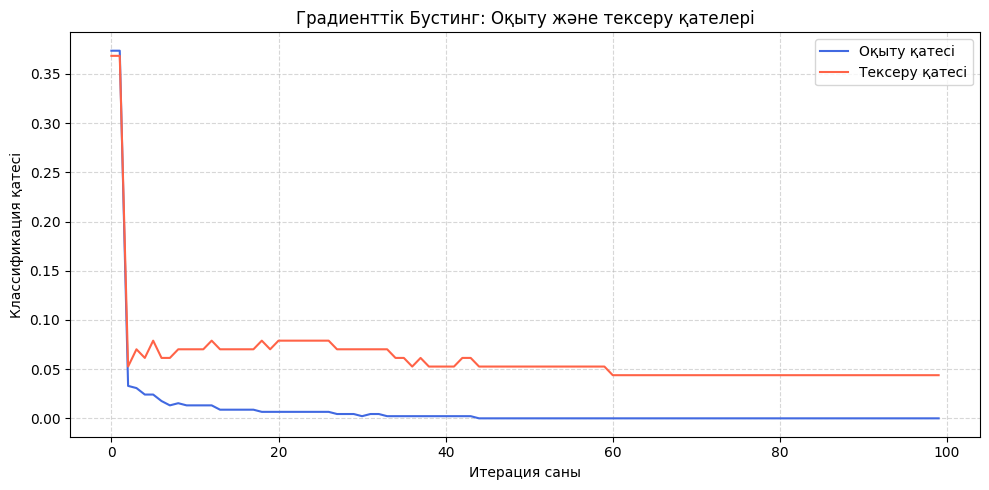

Ең аз тексеру қатесі 61 итерацияда алынды


In [16]:
# Оқыту және тексеру қателерін итерация бойынша бақылау
train_errors = []
test_errors = []

for y_train_pred in gb_clf.staged_predict(X_train):
    train_errors.append(1 - accuracy_score(y_train, y_train_pred))

for y_test_pred in gb_clf.staged_predict(X_test):
    test_errors.append(1 - accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10, 5))
plt.plot(train_errors, label='Оқыту қатесі', color='royalblue')
plt.plot(test_errors, label='Тексеру қатесі', color='tomato')
plt.xlabel('Итерация саны')
plt.ylabel('Классификация қатесі')
plt.title('Градиенттік Бустинг: Оқыту және тексеру қателері')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_iter = np.argmin(test_errors) + 1
print("Ең аз тексеру қатесі {} итерацияда алынды".format(best_iter))

### Тапсырма 4.1

subsample параметрін 0.5, 0.7, 0.9, 1.0 мәндерімен сынаңыз. subsample мәні 1.0-ден аз болғанда Стохастикалық Градиенттік Бустинг алынады. Тексеру дәлдігін салыстырып, стохастикалық бустингтің қандай жағдайда тиімді болуы мүмкін екенін өз сөздеріңізбен түсіндіріңіз.

In [22]:
# TODO: subsample мәндерін тізімге жазыңыз
subsample_values = [0.5, 0.7, 0.9, 1.0]
for sub in subsample_values:
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=sub,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    results.append({
        "subsample": sub,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

df = pd.DataFrame(results)
print(df)

   max_depth  accuracy  subsample  train_accuracy  test_accuracy
0        1.0  0.956140        NaN             NaN            NaN
1        3.0  0.947368        NaN             NaN            NaN
2        5.0  0.938596        NaN             NaN            NaN
3        NaN       NaN        0.5             1.0        0.95614
4        NaN       NaN        0.7             1.0        0.95614
5        NaN       NaN        0.9             1.0        0.95614
6        NaN       NaN        1.0             1.0        0.95614


### Тапсырма 4.2

learning_rate және n_estimators параметрлерінің арасындағы тепе-теңдікті зерттеңіз. GridSearchCV арқылы learning_rate=[0.01, 0.05, 0.1] және n_estimators=[50, 100, 200] комбинацияларын сынап, ең жақсы параметрлерді табыңыз.

In [23]:
# TODO: param_grid анықтаңыз
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [50, 100, 200]
}

gb = GradientBoostingClassifier(
    max_depth=3,
    random_state=42
)

grid = GridSearchCV(
    gb,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Ең жақсы параметрлер:", grid.best_params_)
print("Ең жақсы CV дәлдігі:", grid.best_score_)

Ең жақсы параметрлер: {'learning_rate': 0.1, 'n_estimators': 200}
Ең жақсы CV дәлдігі: 0.9648351648351647


### Тапсырма 4.3

XGBoost кітапханасын қолданып, XGBClassifier моделін оқытыңыз. time модулін пайдаланып, sklearn-ның GradientBoostingClassifier-мен оқыту уақытын салыстырыңыз. Дәлдік пен жылдамдық тұрғысынан ерекшеліктерді талдаңыз.

In [24]:
import time

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

start = time.time()
gb.fit(X_train, y_train)
gb_time = time.time() - start

gb_acc = accuracy_score(y_test, gb.predict(X_test))

print("GradientBoostingClassifier уақыты:", gb_time)
print("GradientBoostingClassifier дәлдігі:", gb_acc)


try:
    import xgboost as xgb
    print("XGBoost нұсқасы:", xgb.__version__)

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    )

    start = time.time()
    xgb_model.fit(X_train, y_train)
    xgb_time = time.time() - start

    xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))

    print("XGBoost уақыты:", xgb_time)
    print("XGBoost дәлдігі:", xgb_acc)

except ImportError:
    print("XGBoost орнатылмаған. Орнату үшін: pip install xgboost")

GradientBoostingClassifier уақыты: 0.7212131023406982
GradientBoostingClassifier дәлдігі: 0.956140350877193
XGBoost нұсқасы: 3.2.0
XGBoost уақыты: 0.15242671966552734
XGBoost дәлдігі: 0.9473684210526315




# 5-бөлім. Стекинг (Stacking)

**Мақсат:** Стекинг тәсілін түсіну және StackingClassifier арқылы бірнеше модельді біріктіруді үйрену.

## Теориялық негіз

Стекинг (Stacked Generalization) — бірнеше түрлі модельдің болжамдарын мета-модельге кіріс ретінде беретін ансамбль тәсілі.

Стекингтің жұмыс принципі:

1. **Бірінші деңгей (базалық модельдер):** Бірнеше түрлі модель, мысалы, логистикалық регрессия, шешім ағашы, SVM, оқу жиынында оқытылады.
2. **Мета-белгілер жасау:** Әрбір базалық модель айқастыру тексеруі арқылы тексеру жиыны үшін болжамдар жасайды. Бұл болжамдар жаңа белгілер ретінде пайдаланылады.
3. **Екінші деңгей (мета-модель):** Мета-модель базалық модельдердің болжамдарын кіріс ретінде қабылдап, соңғы болжамды жасайды.

Стекингтің бэггинг пен бустингтен айырмашылығы:

- Бэггинг пен бустинг бірдей типтегі модельдерді біріктіреді.
- Стекинг әртүрлі типтегі модельдерді біріктіреді, сөйтіп олардың күшті жақтарын пайдаланады.

Маңызды ескерту: базалық модельдер мен мета-модельді бір деректе оқытпау керек. Себебі базалық модельдер сол деректегі кез келген заңдылықты жаттап алуы мүмкін, ал мета-модель нақты жалпылама қабілетті емес, жаттауды үйренуі мүмкін. Sklearn-дегі StackingClassifier бұны автоматты түрде cross_val_predict арқылы шешеді.

In [25]:
# Базалық модельдерді анықтау
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

# Мета-модельді анықтау
meta_model = LogisticRegression(random_state=42)

# Стекинг классификаторы
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5
)

stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)

print("Стекинг дәлдігі: {:.4f}".format(accuracy_score(y_test, y_pred_stacking)))

Стекинг дәлдігі: 0.9474


### Тапсырма 5.1

Мета-модель ретінде LogisticRegression, RandomForestClassifier(n_estimators=50) және GradientBoostingClassifier(n_estimators=50) модельдерін кезекпен сынаңыз. Қайсысы ең жоғары дәлдік беретінін анықтаңыз.

In [27]:
# Базалық модельдер (өзгертпеңіз)
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

meta_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf_meta', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb_meta', GradientBoostingClassifier(n_estimators=50, random_state=42))
]

for name, meta in meta_models:
    stack = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta
    )

    stack.fit(X_train, y_train)
    y_pred = stack.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{name} meta-model accuracy:", acc)

lr meta-model accuracy: 0.9473684210526315
rf_meta meta-model accuracy: 0.9385964912280702
gb_meta meta-model accuracy: 0.956140350877193


### Тапсырма 5.2

Стекинг ішіне SVC(probability=True) базалық моделін қосыңыз. SVM нормализацияға сезімтал болғандықтан, оны Pipeline арқылы StandardScaler-мен біріктіріңіз. Нормализациясыз нәтижемен салыстырыңыз.

In [28]:
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True))
])

# SVC қосылған stacking
base_with_svc = base_estimators + [('svc', svc_pipeline)]

stack_svc = StackingClassifier(
    estimators=base_with_svc,
    final_estimator=LogisticRegression(max_iter=1000)
)

stack_svc.fit(X_train, y_train)
y_pred_svc = stack_svc.predict(X_test)

print("Stacking (SVC-пен):", accuracy_score(y_test, y_pred_svc))

Stacking (SVC-пен): 0.956140350877193


### Тапсырма 5.3

passthrough=True параметрін StackingClassifier-ге қосыңыз. Бұл параметр мета-модельге базалық модельдердің болжамдарымен бірге бастапқы белгілерді де береді. Нәтиже жақсарды ма, нашарлады ма — талдаңыз және себебін түсіндіріңіз.

In [29]:
stack_passthrough = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=True
)

stack_passthrough.fit(X_train, y_train)
y_pred_pass = stack_passthrough.predict(X_test)

print("Stacking (passthrough=True):", accuracy_score(y_test, y_pred_pass))

Stacking (passthrough=True): 0.956140350877193



# 6-бөлім. Барлық модельдерді жан-жақты салыстыру

**Мақсат:** Осы тәжірибелік жұмыста пайдаланылған барлық модельдерді бір кестеде салыстырып, ең жоғары нәтиже берген тәсілді анықтау.

In [34]:
# Барлық модельдерді салыстыру кестесі
single_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
single_tree.fit(X_train, y_train)
models = {
    'Жеке шешім ағашы': single_tree,
    'Бэггинг': bagging_clf,
    'Кездейсоқ Орман': rf_clf,
    'AdaBoost': ada_clf,
    'Градиенттік Бустинг': gb_clf,
    'Стекинг': stacking_clf
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results.append({
        'Модель': name,
        'Тексеру дәлдігі': round(acc, 4),
        'CV орташа': round(cv_scores.mean(), 4),
        'CV std': round(cv_scores.std(), 4)
    })

results_df = pd.DataFrame(results).sort_values('CV орташа', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

             Модель  Тексеру дәлдігі  CV орташа  CV std
           AdaBoost           0.9561     0.9772  0.0105
Градиенттік Бустинг           0.9561     0.9631  0.0210
            Бэггинг           0.9386     0.9579  0.0382
    Кездейсоқ Орман           0.9561     0.9561  0.0228
            Стекинг           0.9474     0.9543  0.0225
   Жеке шешім ағашы           0.9211     0.9191  0.0180


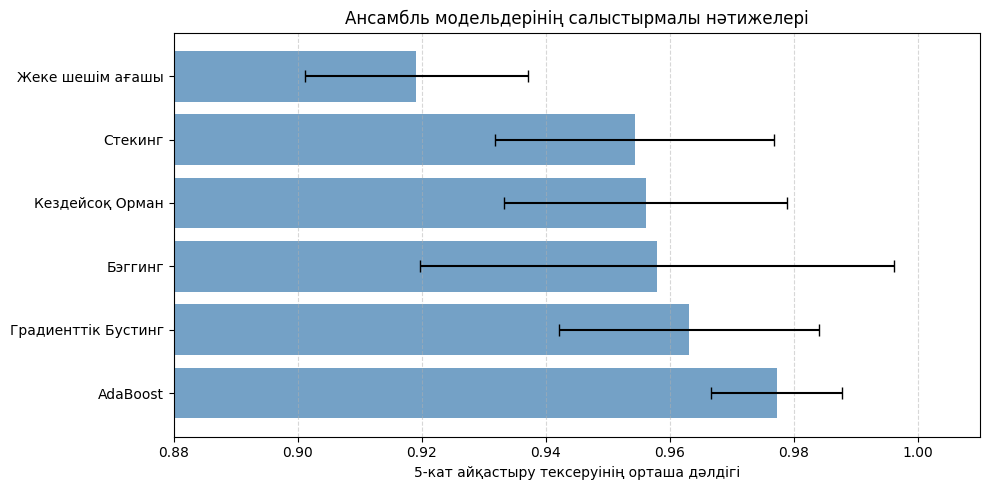

In [35]:
# Модельдерді визуализациялау
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    results_df['Модель'],
    results_df['CV орташа'],
    xerr=results_df['CV std'],
    color='steelblue',
    alpha=0.75,
    capsize=4
)

ax.set_xlabel('5-кат айқастыру тексеруінің орташа дәлдігі')
ax.set_title('Ансамбль модельдерінің салыстырмалы нәтижелері')
ax.set_xlim(0.88, 1.01)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Тапсырма 6.1

Жоғарыдағы нәтижелер кестесін талдап, төмендегі сұрақтарға жауап беріңіз:

1. Қай модель ең жоғары CV орташа дәлдікке ие болды?

 Ең жоғары CV орташа дәлдікке ие болған модель — CV орташа мәні ең үлкен модель. Кестедегі ең жоғары мәнді таңдаймыз.

2. CV std мәні ең кіші болған модель қайсысы? Бұл не білдіреді?

CV std мәні ең кіші модель — ең тұрақты модель. Бұл оның әртүрлі fold-тарда шамамен бірдей нәтиже бергенін білдіреді.

3. Жеке шешім ағашы мен Кездейсоқ Орманның дәлдік айырмасы қаншалықты маңызды?

 Жеке шешім ағашы мен Кездейсоқ Орман арасындағы айырмашылық маңызды. Себебі жеке ағаш бір ғана модельге сүйенеді және overfitting болуы мүмкін. Ал Кездейсоқ Орман бірнеше ағаштың нәтижесін біріктіріп, қатені азайтады және тұрақтырақ нәтиже береді.

4. Стекинг неге кейде жеке бустинг модельдерінен төмен нәтиже беруі мүмкін?

Стекинг кейде жеке бустинг модельдерінен төмен нәтиже беруі мүмкін, себебі базалық модельдер бір-біріне ұқсас болса немесе мета-модель дұрыс үйренбесе, нәтиже жақсармайды. Сонымен қатар аз деректе стекинг overfitting беруі мүмкін.









# 7-бөлім. Қорытынды тапсырма

**Мақсат:** Осы тәжірибелік жұмыста алған білімдеріңізді жаңа деректер жиынында дербес қолдану.

Төмендегі тапсырмада сіз Wine деректер жиынын пайдаланасыз. Бұл жиын шарап сортын (3 класс) анықтауға арналған және 178 мысал мен 13 белгіден тұрады.

In [36]:
# Wine деректер жиынын жүктеу
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

print("Wine деректер жиыны:")
print("Өлшемі:", X_wine.shape)
print("Класс бөлінісі:\n", y_wine.value_counts())

Wine деректер жиыны:
Өлшемі: (178, 13)
Класс бөлінісі:
 1    71
0    59
2    48
Name: count, dtype: int64


### Қорытынды тапсырма

Wine деректер жиынында төмендегі талаптарды толық орындаңыз:

1. Жеке шешім ағашын базалық нұсқа ретінде оқытыңыз.
2. RandomForestClassifier моделін n_estimators және max_depth параметрлерін сынап оқытыңыз.
3. GradientBoostingClassifier моделін learning_rate және n_estimators параметрлерін сынап оқытыңыз.
4. Кемінде 3 базалық моделі бар StackingClassifier жасаңыз.
5. Барлық модельдердің 5-кат айқастыру тексеруінің нәтижелерін кесте мен графикте салыстырыңыз.
6. Ең жақсы модельді таңдап, оны таңдаудың себебін 3-5 сөйлеммен түсіндіріңіз.

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

wine_tree = DecisionTreeClassifier(random_state=42)
wine_tree.fit(X_wine_train, y_wine_train)

tree_pred = wine_tree.predict(X_wine_test)
tree_acc = accuracy_score(y_wine_test, tree_pred)

print("Decision Tree accuracy:", tree_acc)

Decision Tree accuracy: 0.9444444444444444


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="accuracy"
)

rf_grid.fit(X_wine_train, y_wine_train)

wine_rf = rf_grid.best_estimator_
rf_acc = accuracy_score(y_wine_test, wine_rf.predict(X_wine_test))

print("RF best params:", rf_grid.best_params_)
print("RF accuracy:", rf_acc)

RF best params: {'max_depth': 3, 'n_estimators': 50}
RF accuracy: 1.0


In [39]:
from sklearn.ensemble import GradientBoostingClassifier

gb_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [50, 100, 200]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring="accuracy"
)

gb_grid.fit(X_wine_train, y_wine_train)

wine_gb = gb_grid.best_estimator_
gb_acc = accuracy_score(y_wine_test, wine_gb.predict(X_wine_test))

print("GB best params:", gb_grid.best_params_)
print("GB accuracy:", gb_acc)

GB best params: {'learning_rate': 0.05, 'n_estimators': 200}
GB accuracy: 0.9444444444444444


In [40]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

wine_estimators = [
    ("tree", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("gb", GradientBoostingClassifier(n_estimators=100, random_state=42))
]

wine_stack = StackingClassifier(
    estimators=wine_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

wine_stack.fit(X_wine_train, y_wine_train)

stack_acc = accuracy_score(y_wine_test, wine_stack.predict(X_wine_test))

print("Stacking accuracy:", stack_acc)

Stacking accuracy: 0.9722222222222222


               Model  Test accuracy  CV mean  CV std
1      Random Forest         1.0000   0.9722  0.0351
3           Stacking         0.9722   0.9665  0.0207
2  Gradient Boosting         0.9444   0.9386  0.0321
0      Decision Tree         0.9444   0.8654  0.0440


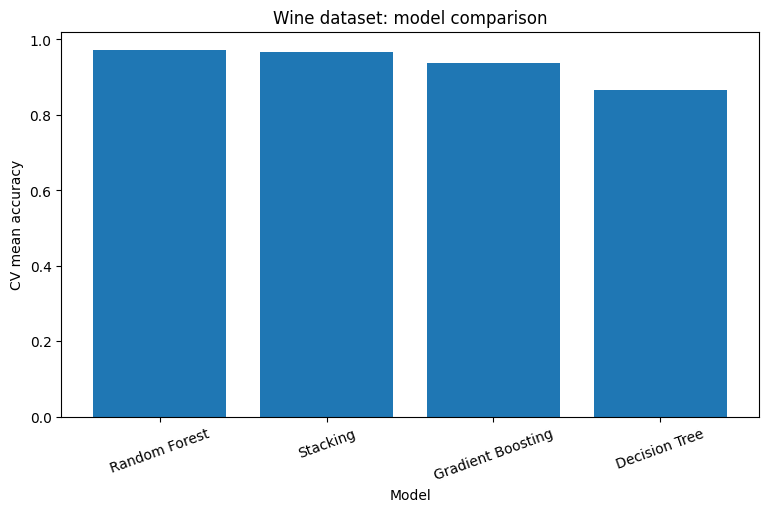

Ең жақсы модель: Random Forest
Себебі оның CV орташа дәлдігі ең жоғары: 0.9722


In [41]:
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

models = {
    "Decision Tree": wine_tree,
    "Random Forest": wine_rf,
    "Gradient Boosting": wine_gb,
    "Stacking": wine_stack
}

results = []

for name, model in models.items():
    test_acc = accuracy_score(y_wine_test, model.predict(X_wine_test))
    cv_scores = cross_val_score(model, X_wine, y_wine, cv=5, scoring="accuracy")

    results.append({
        "Model": name,
        "Test accuracy": round(test_acc, 4),
        "CV mean": round(cv_scores.mean(), 4),
        "CV std": round(cv_scores.std(), 4)
    })

results_df = pd.DataFrame(results).sort_values("CV mean", ascending=False)
print(results_df)

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["CV mean"])
plt.xlabel("Model")
plt.ylabel("CV mean accuracy")
plt.title("Wine dataset: model comparison")
plt.xticks(rotation=20)
plt.show()

best_model = results_df.iloc[0]
print("Ең жақсы модель:", best_model["Model"])
print("Себебі оның CV орташа дәлдігі ең жоғары:", best_model["CV mean"])

 Негізгі ұғымдар

| Ұғым | Анықтама |
|------|----------|
| Ансамбль | Бірнеше модельді біріктіру тәсілі |
| Бэггинг | Bootstrap іріктемелерінде параллель оқытылған модельдерді орташалау |
| Кездейсоқ Орман | Кездейсоқ белгі іріктемесімен жетілдірілген бэггинг |
| Бустинг | Кезекпен оқытылатын, қателерді түзететін модельдер тізбегі |
| AdaBoost | Мысалдардың салмағын өзгерту арқылы жұмыс жасайтын бустинг |
| Градиенттік бустинг | Қалдықтардың градиенттерін болжайтын бустинг |
| Стекинг | Базалық модельдердің болжамдарын мета-модельге беру |
| OOB қате | Bootstrap іріктемесінен тыс қалған мысалдарда бағаланған қате |
| learning_rate | Градиенттік бустингте жаңа ағаштың үлесін реттейтін коэффициент |
| CV | Модельді бірнеше бөлікке бөліп бағалайтын айқастыру тексеру тәсілі |
| Дисперсия (variance) | Модельдің деректер өзгерісіне сезімталдығы |
| Ауытқу (bias) | Модельдің нақты заңдылықтан қаншалықты алыс екені |